# 07 Feature Group Ablation

This notebook evaluates how XGBoost holdout performance changes when one feature group is removed from the full feature set.

The full-feature XGBoost result from the model comparison is used as the reference setting. XGBoost is then retrained under leave-one-group-out feature configurations and evaluated on the same fixed temporal holdout test set. The notebook produces the feature-group ablation table and the change-in-F1 figure used in the thesis.

## 1. Experiment overview

This section summarizes the feature-group ablation setup used in the thesis.

- **Input data:** temporal training and holdout files generated by the split notebook
- **Model:** XGBoost
- **Validation strategy:** stratified 5-fold cross-validation within the training set
- **Hyperparameter search:** grid search with F1-score as the selection metric
- **Feature-set design:** full feature set versus leave-one-group-out ablations
- **Final evaluation:** fixed temporal holdout test set
- **Threshold:** 0.5 for threshold-dependent metrics
- **Reported metrics:** F1-score, precision, recall, accuracy, and ROC-AUC

The full-feature result is loaded from the model comparison output. The ablation models are trained in this notebook.

In [1]:
from __future__ import annotations

from pathlib import Path
import sys
import json
import joblib
import platform
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

pd.set_option("display.float_format", "{:.2f}".format)

## 2. Project paths and experiment settings

This section defines the input files, output locations, and shared modeling settings.

In [2]:
PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"
INTERIM_DIR = DATA_DIR / "interim"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
TABLES_DIR = OUTPUTS_DIR / "tables"
FIGURES_DIR = OUTPUTS_DIR / "figures"
LOGS_DIR = OUTPUTS_DIR / "logs"
MODELS_DIR = OUTPUTS_DIR / "models"

MODEL_COMPARISON_TABLES_DIR = TABLES_DIR / "model_comparison"
FEATURE_GROUP_TABLES_DIR = TABLES_DIR / "feature_group_ablation"
FEATURE_GROUP_FIGURE_DIR = FIGURES_DIR / "feature_group_ablation"
FEATURE_GROUP_LOG_DIR = LOGS_DIR / "feature_group_ablation"
FEATURE_GROUP_MODEL_DIR = MODELS_DIR / "feature_group_ablation"

X_TRAIN_PATH = INTERIM_DIR / "X_train_temporal.csv"
X_TEST_PATH = INTERIM_DIR / "X_test_temporal.csv"
Y_TRAIN_PATH = INTERIM_DIR / "y_train_temporal.csv"
Y_TEST_PATH = INTERIM_DIR / "y_test_temporal.csv"

MODEL_COMPARISON_RESULTS_PATH = MODEL_COMPARISON_TABLES_DIR / "model_comparison_results.csv"
MODEL_COMPARISON_BEST_PARAMS_PATH = MODEL_COMPARISON_TABLES_DIR / "model_comparison_best_params.csv"

TARGET_COL = "target"
RANDOM_SEED = 2026
CV_FOLDS = 5
THRESHOLD = 0.5
SCORING = "f1"

CATEGORICAL_COLUMNS = ["country_code", "market"]

GRIDSEARCH_N_JOBS = -1
GRIDSEARCH_VERBOSE = 1

OUTPUT_PATHS = {
    "comparison": FEATURE_GROUP_TABLES_DIR / "feature_group_ablation_results.csv",
    "metric_differences": FEATURE_GROUP_TABLES_DIR / "feature_group_ablation_metric_differences.csv",
    "best_params": FEATURE_GROUP_TABLES_DIR / "xgboost_feature_group_ablation_best_params.csv",
    "ablation_predictions": FEATURE_GROUP_TABLES_DIR / "xgboost_feature_group_ablation_holdout_predictions.csv",
    "feature_set_summary": FEATURE_GROUP_TABLES_DIR / "feature_group_ablation_feature_set_summary.csv",
    "gridsearch_log": FEATURE_GROUP_LOG_DIR / "xgboost_feature_group_ablation_gridsearch_log.csv",
    "f1_change_figure": FEATURE_GROUP_FIGURE_DIR / "change_in_f1_after_removing_feature_groups.png",
    "run_metadata": FEATURE_GROUP_TABLES_DIR / "feature_group_ablation_run_metadata.json",
}

for directory in [FEATURE_GROUP_TABLES_DIR, FEATURE_GROUP_FIGURE_DIR, FEATURE_GROUP_LOG_DIR, FEATURE_GROUP_MODEL_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

## 3. Hyperparameter search space

This section defines the XGBoost grid-search space reported in the methodology section.

In [3]:
XGB_PARAMS = {
    "model__n_estimators": [100, 300, 500],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [3, 5, 7],
    "model__min_child_weight": [1, 3, 5],
    "model__subsample": [0.7, 1.0],
    "model__colsample_bytree": [0.7, 1.0],
}

search_space_summary = pd.DataFrame([{
    "model": "XGBoost",
    "n_parameter_settings": int(np.prod([len(v) for v in XGB_PARAMS.values()])),
}])
search_space_summary["n_cv_fits"] = search_space_summary["n_parameter_settings"] * CV_FOLDS

display(search_space_summary)

,model,n_parameter_settings,n_cv_fits
0,XGBoost,324,1620


## 4. Helper functions

This section defines functions for loading data, constructing XGBoost pipelines, evaluating holdout performance, and summarizing grid-search outputs.

In [4]:
def check_required_files(paths: list[Path]) -> None:
    missing = [str(path) for path in paths if not path.exists()]
    if missing:
        raise FileNotFoundError(
            "The following required input files are missing:\n"
            + "\n".join(missing)
            + "\n\nRun the preprocessing, temporal split, and model comparison notebooks first, or update the paths in Section 2."
        )


def read_target(path: Path, target_col: str = TARGET_COL) -> pd.Series:
    target_df = pd.read_csv(path)
    if target_col not in target_df.columns:
        raise ValueError(f"Target column '{target_col}' was not found in {path}.")
    return target_df[target_col].astype(int)


def load_temporal_split_inputs() -> tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    check_required_files([X_TRAIN_PATH, X_TEST_PATH, Y_TRAIN_PATH, Y_TEST_PATH])
    X_train = pd.read_csv(X_TRAIN_PATH)
    X_test = pd.read_csv(X_TEST_PATH)
    y_train = read_target(Y_TRAIN_PATH)
    y_test = read_target(Y_TEST_PATH)
    return X_train, X_test, y_train, y_test


def load_xgboost_reference_result() -> pd.DataFrame:
    check_required_files([MODEL_COMPARISON_RESULTS_PATH])
    model_results = pd.read_csv(MODEL_COMPARISON_RESULTS_PATH)

    required_columns = {"model", "f1"}
    missing_columns = required_columns.difference(model_results.columns)
    if missing_columns:
        raise ValueError(f"The model comparison results file is missing required columns: {sorted(missing_columns)}")

    xgb_rows = model_results.loc[
        model_results["model"].astype(str).str.lower().eq("xgboost")
    ].copy()

    if xgb_rows.empty:
        raise ValueError("No XGBoost row was found in the model comparison results file.")

    xgb_rows["feature_set"] = "Full feature set"
    xgb_rows["removed_feature_group"] = "none"
    xgb_rows["validation_strategy"] = "stratified_cv"
    xgb_rows["source"] = "model_comparison_output"

    return xgb_rows


def load_xgboost_reference_best_params() -> pd.DataFrame:
    if not MODEL_COMPARISON_BEST_PARAMS_PATH.exists():
        return pd.DataFrame()

    best_params = pd.read_csv(MODEL_COMPARISON_BEST_PARAMS_PATH)
    if "model" not in best_params.columns:
        return pd.DataFrame()

    xgb_params = best_params.loc[
        best_params["model"].astype(str).str.lower().eq("xgboost")
    ].copy()

    if xgb_params.empty:
        return pd.DataFrame()

    xgb_params["feature_set"] = "Full feature set"
    xgb_params["removed_feature_group"] = "none"

    column_order = [
        "model",
        "feature_set",
        "removed_feature_group",
        "parameter",
        "compared_values",
        "best_value",
    ]
    for column in column_order:
        if column not in xgb_params.columns:
            xgb_params[column] = np.nan

    return xgb_params[column_order]


def select_columns(
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    selected_columns: list[str],
) -> tuple[pd.DataFrame, pd.DataFrame, list[str], list[str]]:
    present = [column for column in selected_columns if column in X_train.columns and column in X_test.columns]
    missing = [column for column in selected_columns if column not in X_train.columns or column not in X_test.columns]

    if not present:
        raise ValueError("None of the selected features were found in both X_train and X_test.")

    return X_train[present].copy(), X_test[present].copy(), present, missing


def make_one_hot_encoder() -> OneHotEncoder:
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=True)


def make_preprocessor(X_train: pd.DataFrame, categorical_columns: list[str]) -> ColumnTransformer:
    categorical_present = [column for column in categorical_columns if column in X_train.columns]
    numeric_present = [column for column in X_train.columns if column not in categorical_present]

    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
    ])

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="other")),
        ("onehot", make_one_hot_encoder()),
    ])

    return ColumnTransformer(
        transformers=[
            ("numeric", numeric_pipeline, numeric_present),
            ("categorical", categorical_pipeline, categorical_present),
        ],
        remainder="drop",
    )


def make_xgboost_pipeline(X_train: pd.DataFrame, categorical_columns: list[str]) -> Pipeline:
    return Pipeline([
        ("preprocessor", make_preprocessor(X_train, categorical_columns)),
        ("model", XGBClassifier(
            random_state=RANDOM_SEED,
            eval_metric="logloss",
            n_jobs=1,
            tree_method="hist",
        )),
    ])


def evaluate_binary_classifier(
    fitted_model: Pipeline,
    X_test: pd.DataFrame,
    y_test: pd.Series,
    threshold: float = THRESHOLD,
) -> tuple[dict, pd.DataFrame]:
    y_prob = fitted_model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()

    metrics = {
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "accuracy": accuracy_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_prob),
        "true_negative": int(tn),
        "false_positive": int(fp),
        "false_negative": int(fn),
        "true_positive": int(tp),
    }

    predictions = pd.DataFrame({
        "y_true": y_test.to_numpy(),
        "y_pred": y_pred,
        "y_prob": y_prob,
    })

    return metrics, predictions


def summarize_best_params(feature_set: str, removed_feature_group: str, search: GridSearchCV) -> pd.DataFrame:
    rows = []
    for parameter, compared_values in search.param_grid.items():
        rows.append({
            "model": "XGBoost",
            "feature_set": feature_set,
            "removed_feature_group": removed_feature_group,
            "parameter": parameter.replace("model__", ""),
            "compared_values": ", ".join(map(str, compared_values)),
            "best_value": search.best_params_.get(parameter),
        })
    return pd.DataFrame(rows)


def summarize_cv_results(feature_set: str, removed_feature_group: str, search: GridSearchCV) -> pd.DataFrame:
    log_df = pd.DataFrame(search.cv_results_)
    log_df.insert(0, "feature_set", feature_set)
    log_df.insert(1, "removed_feature_group", removed_feature_group)
    return log_df


def check_no_unexpected_features(selected_features: list[str], feature_set_name: str) -> None:
    excluded_features_check = [
        "grant",
        "convertible_note",
        "product_crowdfunding",
        "equity_crowdfunding",
        "round_f",
        "round_g",
        "round_h",
        "post_ipo_equity",
        "post_ipo_debt",
        "secondary_market",
        "is_usa",
        "first_funding_at",
        "last_funding_at",
    ]

    unexpected_selected_features = [
        feature for feature in excluded_features_check
        if feature in selected_features
    ]

    if unexpected_selected_features:
        raise ValueError(
            f"The feature set '{feature_set_name}' contains variables that should be excluded: "
            f"{unexpected_selected_features}."
        )

## 5. Load data and full-feature reference result

This section loads the temporal split data and the full-feature XGBoost result from the model comparison output.

In [5]:
X_train_raw, X_test_raw, y_train, y_test = load_temporal_split_inputs()
full_feature_reference = load_xgboost_reference_result()
full_feature_best_params = load_xgboost_reference_best_params()

split_summary = pd.DataFrame([
    {"dataset": "training", "n_observations": len(X_train_raw), "n_columns": X_train_raw.shape[1]},
    {"dataset": "holdout", "n_observations": len(X_test_raw), "n_columns": X_test_raw.shape[1]},
])

display(split_summary)
display(full_feature_reference[["model", "feature_set", "f1", "precision", "recall", "accuracy", "roc_auc"]].round(2))

,dataset,n_observations,n_columns
0,training,4563,22
1,holdout,1141,22


,model,feature_set,f1,precision,recall,accuracy,roc_auc
0,XGBoost,Full feature set,0.81,0.79,0.82,0.73,0.77


## 6. Define full and leave-one-group-out feature sets

This section defines the feature groups used for the ablation experiment.

In [6]:
feature_blocks = {
    "funding_scale": [
        "funding_total_usd",
        "seed",
        "venture",
        "angel",
        "debt_financing",
        "private_equity",
        "undisclosed",
    ],
    "funding_dynamics": [
        "founded_year",
        "funding_rounds",
        "funding_duration_days",
        "avg_days_between_rounds",
        "is_single_round",
    ],
    "stage_structure": [
        "has_round_a",
        "has_round_b",
        "has_round_c",
        "has_round_d",
        "has_round_e",
    ],
    "geography": ["country_code"],
    "industry": ["market"],
}

feature_group_labels = {
    "funding_scale": "Funding scale",
    "funding_dynamics": "Funding dynamics",
    "stage_structure": "Stage structure",
    "geography": "Geography",
    "industry": "Industry",
}

full_feature_set = [feature for features in feature_blocks.values() for feature in features]

feature_sets = {"Full feature set": full_feature_set}
for group_name, group_features in feature_blocks.items():
    feature_sets[f"Without {feature_group_labels[group_name].lower()}"] = [
        feature for feature in full_feature_set if feature not in group_features
    ]

feature_set_summary_rows = []

for feature_set_name, candidate_features in feature_sets.items():
    _, _, selected_features, missing_features = select_columns(
        X_train_raw,
        X_test_raw,
        candidate_features,
    )
    check_no_unexpected_features(selected_features, feature_set_name)

    removed_feature_group = "none"
    if feature_set_name.startswith("Without "):
        removed_feature_group = feature_set_name.replace("Without ", "")

    feature_set_summary_rows.append({
        "feature_set": feature_set_name,
        "removed_feature_group": removed_feature_group,
        "n_requested_features": len(candidate_features),
        "n_available_features": len(selected_features),
        "missing_features": ", ".join(missing_features),
        "selected_features": ", ".join(selected_features),
    })

feature_set_summary_df = pd.DataFrame(feature_set_summary_rows)

display(feature_set_summary_df[[
    "feature_set",
    "removed_feature_group",
    "n_requested_features",
    "n_available_features",
    "missing_features",
]])

,feature_set,removed_feature_group,n_requested_features,n_available_features,missing_features
0,Full feature set,none,19,19,
1,Without funding scale,funding scale,12,12,
2,Without funding dynamics,funding dynamics,14,14,
3,Without stage structure,stage structure,14,14,
4,Without geography,geography,18,18,
5,Without industry,industry,18,18,


## 7. Train XGBoost ablation models

This section retrains XGBoost after removing one feature group at a time.

In [7]:
cv = StratifiedKFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_SEED,
)

ablation_results = []
ablation_predictions = []
ablation_best_params = []
gridsearch_logs = []
trained_models = {}

ablation_feature_sets = {
    name: features
    for name, features in feature_sets.items()
    if name != "Full feature set"
}

for feature_set_name, candidate_features in ablation_feature_sets.items():
    removed_feature_group = feature_set_summary_df.loc[
        feature_set_summary_df["feature_set"] == feature_set_name,
        "removed_feature_group",
    ].iloc[0]

    X_train, X_test, selected_features, missing_features = select_columns(
        X_train_raw,
        X_test_raw,
        candidate_features,
    )
    check_no_unexpected_features(selected_features, feature_set_name)

    xgb_pipeline = make_xgboost_pipeline(X_train, CATEGORICAL_COLUMNS)

    search = GridSearchCV(
        estimator=xgb_pipeline,
        param_grid=XGB_PARAMS,
        scoring=SCORING,
        cv=cv,
        n_jobs=GRIDSEARCH_N_JOBS,
        verbose=GRIDSEARCH_VERBOSE,
        refit=True,
        return_train_score=True,
    )

    search.fit(X_train, y_train)

    metrics, predictions = evaluate_binary_classifier(
        fitted_model=search.best_estimator_,
        X_test=X_test,
        y_test=y_test,
        threshold=THRESHOLD,
    )

    metrics.update({
        "model": "XGBoost",
        "feature_set": feature_set_name,
        "removed_feature_group": removed_feature_group,
        "validation_strategy": "stratified_cv",
        "source": "feature_group_ablation",
    })
    ablation_results.append(metrics)

    predictions["model"] = "XGBoost"
    predictions["feature_set"] = feature_set_name
    predictions["removed_feature_group"] = removed_feature_group
    ablation_predictions.append(predictions)

    ablation_best_params.append(
        summarize_best_params(feature_set_name, removed_feature_group, search)
    )

    gridsearch_logs.append(
        summarize_cv_results(feature_set_name, removed_feature_group, search)
    )

    trained_models[feature_set_name] = search.best_estimator_

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Fitting 5 folds for each of 324 candidates, totalling 1620 fits


## 8. Compare full feature set and ablation results

This section combines the full-feature reference result with the leave-one-group-out results.

In [8]:
comparison_columns = [
    "model",
    "feature_set",
    "removed_feature_group",
    "validation_strategy",
    "f1",
    "precision",
    "recall",
    "accuracy",
    "roc_auc",
    "true_negative",
    "false_positive",
    "false_negative",
    "true_positive",
    "source",
]

full_reference = full_feature_reference.copy()
for column in comparison_columns:
    if column not in full_reference.columns:
        full_reference[column] = np.nan
full_reference = full_reference.loc[:, comparison_columns]

ablation_results_df = pd.DataFrame(ablation_results)
for column in comparison_columns:
    if column not in ablation_results_df.columns:
        ablation_results_df[column] = np.nan
ablation_results_for_comparison = ablation_results_df.loc[:, comparison_columns]

feature_group_comparison_df = pd.concat(
    [full_reference, ablation_results_for_comparison],
    ignore_index=True,
)

feature_order = [
    "Full feature set",
    "Without funding scale",
    "Without funding dynamics",
    "Without stage structure",
    "Without geography",
    "Without industry",
]

feature_group_comparison_df["feature_set"] = pd.Categorical(
    feature_group_comparison_df["feature_set"],
    categories=feature_order,
    ordered=True,
)

feature_group_comparison_df = (
    feature_group_comparison_df
    .sort_values("feature_set")
    .reset_index(drop=True)
)

thesis_feature_group_table = feature_group_comparison_df[[
    "feature_set",
    "f1",
    "precision",
    "recall",
    "accuracy",
    "roc_auc",
]].copy()

display(thesis_feature_group_table.round(2))

,feature_set,f1,precision,recall,accuracy,roc_auc
0,Full feature set,0.81,0.79,0.82,0.73,0.77
1,Without funding scale,0.77,0.80,0.74,0.69,0.73
2,Without funding dynamics,0.81,0.79,0.84,0.74,0.75
3,Without stage structure,0.80,0.80,0.81,0.73,0.76
4,Without geography,0.80,0.80,0.81,0.73,0.76
5,Without industry,0.82,0.79,0.84,0.74,0.76


## 9. Compute performance differences and plot F1 change

This section computes metric differences relative to the full feature set and creates the F1-change figure used in the thesis.

,feature_set,removed_feature_group,f1_difference_from_full,precision_difference_from_full,recall_difference_from_full,accuracy_difference_from_full,roc_auc_difference_from_full
0,Full feature set,none,0.00,0.00,0.00,0.00,0.00
1,Without funding scale,funding scale,-0.04,0.01,-0.09,-0.04,-0.04
2,Without funding dynamics,funding dynamics,0.01,-0.00,0.02,0.01,-0.01
3,Without stage structure,stage structure,-0.01,0.01,-0.02,-0.00,-0.01
4,Without geography,geography,-0.00,0.00,-0.01,-0.00,-0.00
5,Without industry,industry,0.01,-0.00,0.02,0.01,-0.01


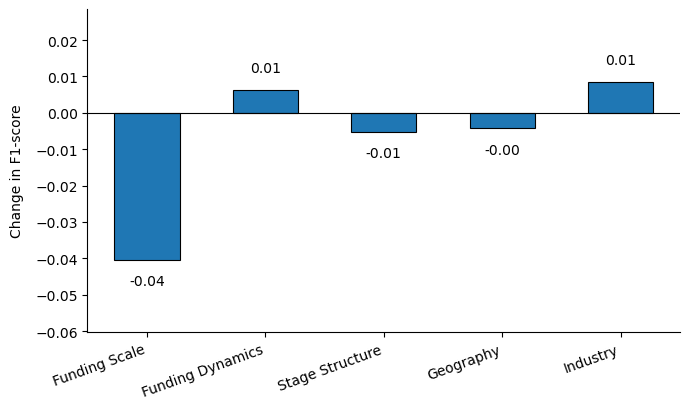

In [9]:
metric_columns = ["f1", "precision", "recall", "accuracy", "roc_auc"]

full_row = feature_group_comparison_df.loc[
    feature_group_comparison_df["feature_set"] == "Full feature set"
]
if full_row.empty:
    raise ValueError("The comparison table does not contain the full feature set reference row.")

full_metrics = full_row.iloc[0][metric_columns].astype(float)

metric_difference_rows = []

for _, row in feature_group_comparison_df.iterrows():
    row_metrics = row[metric_columns].astype(float)
    differences = row_metrics - full_metrics

    metric_difference_rows.append({
        "feature_set": str(row["feature_set"]),
        "removed_feature_group": row["removed_feature_group"],
        **{f"{metric}_difference_from_full": differences[metric] for metric in metric_columns},
    })

metric_differences_df = pd.DataFrame(metric_difference_rows)

feature_group_comparison_df["delta_f1"] = metric_differences_df["f1_difference_from_full"].values

plot_df = feature_group_comparison_df.loc[
    feature_group_comparison_df["feature_set"] != "Full feature set",
    ["feature_set", "delta_f1"],
].copy()

plot_df["feature_set"] = plot_df["feature_set"].astype(str).str.replace("Without ", "", regex=False).str.title()

f1_change_figure, ax = plt.subplots(figsize=(7.0, 4.2))

bars = ax.bar(
    plot_df["feature_set"],
    plot_df["delta_f1"],
    width=0.55,
    edgecolor="black",
    linewidth=0.8,
)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("")
ax.set_ylabel("Change in F1-score", labelpad=8)

min_value = min(plot_df["delta_f1"].min(), 0)
max_value = max(plot_df["delta_f1"].max(), 0)
padding = 0.02
ax.set_ylim(min_value - padding, max_value + padding)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)

for bar in bars:
    height = bar.get_height()
    label_y = height + 0.004 if height >= 0 else height - 0.004
    va = "bottom" if height >= 0 else "top"

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        label_y,
        f"{height:.2f}",
        ha="center",
        va=va,
        fontsize=10,
    )

ax.tick_params(axis="both", labelsize=10)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()

display(metric_differences_df.round(2))
plt.show()

## 10. Save outputs

This section saves the feature-group ablation results, metric differences, selected hyperparameters, holdout predictions, grid-search log, fitted estimators, F1-change figure, and run metadata.

In [10]:
ablation_predictions_df = pd.concat(ablation_predictions, ignore_index=True)
ablation_best_params_df = pd.concat(ablation_best_params, ignore_index=True)
gridsearch_log_df = pd.concat(gridsearch_logs, ignore_index=True)

if not full_feature_best_params.empty:
    best_params_df = pd.concat(
        [full_feature_best_params, ablation_best_params_df],
        ignore_index=True,
    )
else:
    best_params_df = ablation_best_params_df.copy()

feature_group_comparison_df.to_csv(OUTPUT_PATHS["comparison"], index=False)
metric_differences_df.to_csv(OUTPUT_PATHS["metric_differences"], index=False)
best_params_df.to_csv(OUTPUT_PATHS["best_params"], index=False)
ablation_predictions_df.to_csv(OUTPUT_PATHS["ablation_predictions"], index=False)
feature_set_summary_df.to_csv(OUTPUT_PATHS["feature_set_summary"], index=False)
gridsearch_log_df.to_csv(OUTPUT_PATHS["gridsearch_log"], index=False)

f1_change_figure.savefig(
    OUTPUT_PATHS["f1_change_figure"],
    dpi=300,
    bbox_inches="tight",
)

saved_model_paths = {}
for feature_set_name, model in trained_models.items():
    safe_feature_set_name = (
        feature_set_name.lower()
        .replace(" ", "_")
        .replace("-", "_")
    )
    model_path = FEATURE_GROUP_MODEL_DIR / f"xgboost_{safe_feature_set_name}.joblib"
    joblib.dump(model, model_path)
    saved_model_paths[feature_set_name] = str(model_path)

run_metadata = {
    "model": "XGBoost",
    "baseline_reference": "The full-feature XGBoost row is loaded from the model comparison output.",
    "validation_strategy": "stratified_cv",
    "cv_folds": CV_FOLDS,
    "scoring": SCORING,
    "threshold": THRESHOLD,
    "random_seed": RANDOM_SEED,
    "categorical_columns": CATEGORICAL_COLUMNS,
    "feature_sets": feature_set_summary_df.to_dict(orient="records"),
    "input_paths": {
        "X_train": str(X_TRAIN_PATH),
        "X_test": str(X_TEST_PATH),
        "y_train": str(Y_TRAIN_PATH),
        "y_test": str(Y_TEST_PATH),
        "model_comparison_results": str(MODEL_COMPARISON_RESULTS_PATH),
        "model_comparison_best_params": str(MODEL_COMPARISON_BEST_PARAMS_PATH),
    },
    "output_paths": {key: str(value) for key, value in OUTPUT_PATHS.items()},
    "saved_model_paths": saved_model_paths,
}

with open(OUTPUT_PATHS["run_metadata"], "w", encoding="utf-8") as f:
    json.dump(run_metadata, f, indent=2)